# Optics and camara quality study

In [1]:
import cv2
import numpy as np
import os

In [2]:
# Read the input image
image_path = r"C:\Users\mj.j\Documents\2025_08_29_lens_eval_new\16_67.png"
image = cv2.imread(image_path)
if image is None:
    print(f"Warning: Could not read image at {image_path}")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)




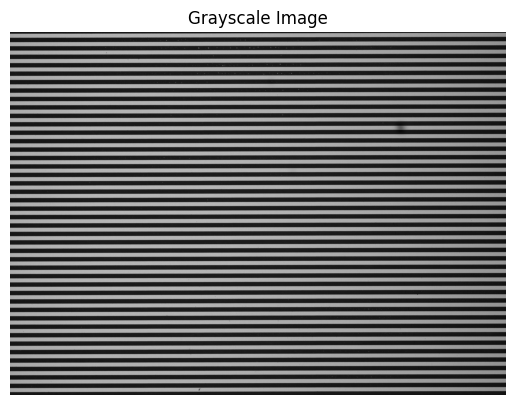

In [3]:
import matplotlib.pyplot as plt

plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

In [4]:
laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
print(f"Laplacian Variance: {laplacian_var}")

Laplacian Variance: 287.9593250324532


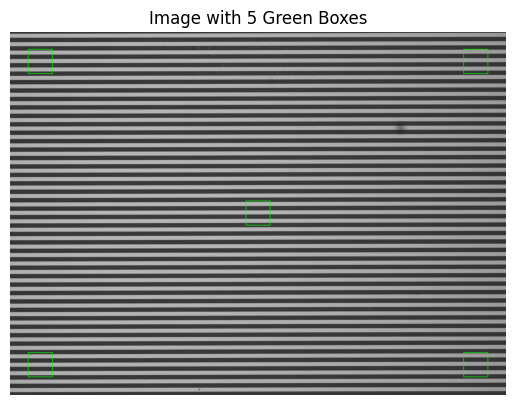

In [5]:
# Define box size and margin
box_size = 200
margin = 150

# Get image dimensions
height, width = image.shape[:2]

# Calculate coordinates for 4 corners and center
boxes = [
    # Top-left
    (margin, margin),
    # Top-right
    (width - margin - box_size, margin),
    # Bottom-left
    (margin, height - margin - box_size),
    # Bottom-right
    (width - margin - box_size, height - margin - box_size),
    # Center
    ((width - box_size) // 2, (height - box_size) // 2)
]

# Draw green boxes
image_with_boxes = image.copy()
for (x, y) in boxes:
    cv2.rectangle(image_with_boxes, (x, y), (x + box_size, y + box_size), (0, 255, 0), 3)




# Show the image with boxes
plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Image with 5 Green Boxes')
plt.axis('off')
plt.show()

In [6]:
# Define the start and end points for the horizontal line
# y = 150
# x_start = 150
# x_end = 350
# box_size = 200
# file_name = f"C:\\Users\\mj.j\\Documents\\2025_08_20_FOV_47_34\\16_67_{x_start}_{y}_to_{x_end}_{y + box_size}.png"


def line_shapness_histrogram(y, x_start, x_end, box_size,file_name):
    sum_of_pixel_values = []
    for y_coord in range(y, y + box_size, 1):

        # Extract the horizontal line of pixels from the grayscale image
        # Note: In numpy, the indexing is [row, column], which corresponds to [y, x]
        horizontal_line = gray[y_coord, x_start:x_end]

        # Calculate the sum of the pixel values along the line
        horizontal_pixel_sum = np.sum(horizontal_line)/box_size

        #print(f" ({x_start}, {y_coord}) to ({x_end}, {y_coord}) is: {horizontal_pixel_sum}")
        sum_of_pixel_values.append(horizontal_pixel_sum)


    # plot sum of pixel values
    plt.plot(range(y, y + box_size, 1), sum_of_pixel_values)
    plt.xlabel("Y Coordinate")
    plt.ylabel("Average Pixel Value")
    plt.grid()
    plt.ylim(0, 255)
    plt.title(f"Average Pixel Value along Horizontal Line, {x_start, y} to {x_end, y + box_size}")
    plt.savefig(file_name, bbox_inches='tight',dpi=100)
    plt.show()


150 150
350 150


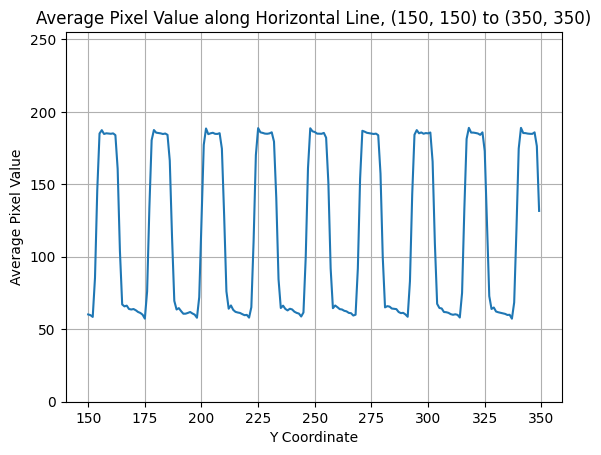

---
3746 150
3946 150


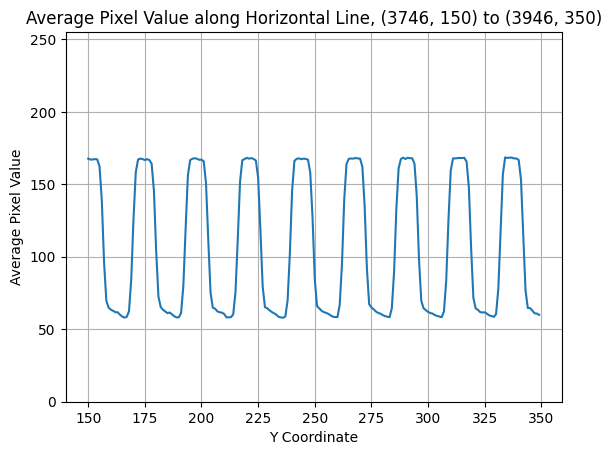

---
150 2650
350 2650


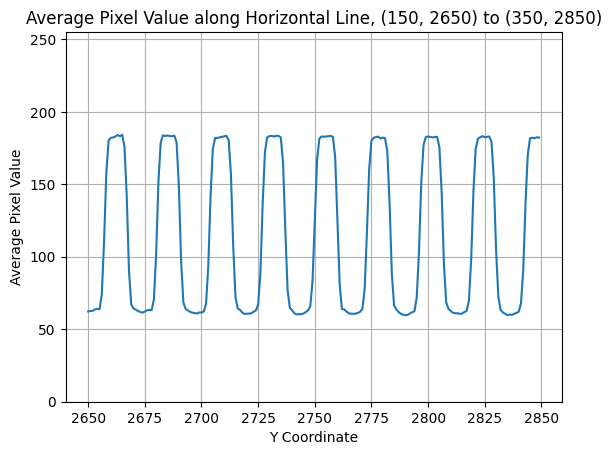

---
3746 2650
3946 2650


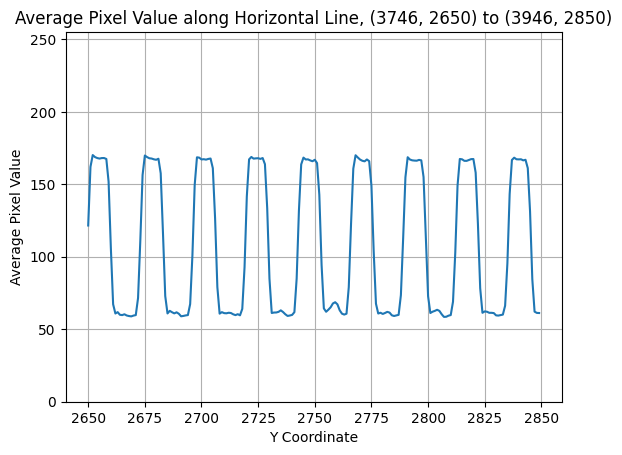

---
1948 1400
2148 1400


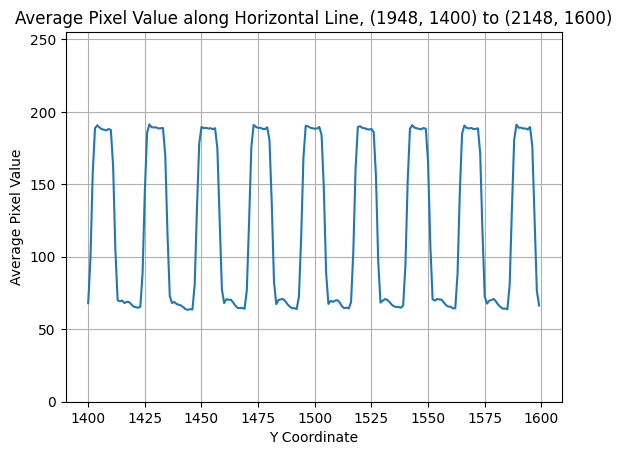

---


In [11]:
# Read the input image
image_path = r"C:\Users\mj.j\Documents\2025_08_29_lens_eval_new\50_00.png"
image = cv2.imread(image_path)
if image is None:
    print(f"Warning: Could not read image at {image_path}")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



for (x, y) in boxes:
    print(x, y)
    print(x + box_size, y)

    x_start = x
    x_end = x + box_size
    file_name = f"C:\\Users\\mj.j\\Documents\\2025_08_29_lens_eval_new\\50_00_{x_start}_{y}_to_{x_end}_{y + box_size}.png"


    line_shapness_histrogram(y, x_start, x_end, box_size,file_name)
    print("---")

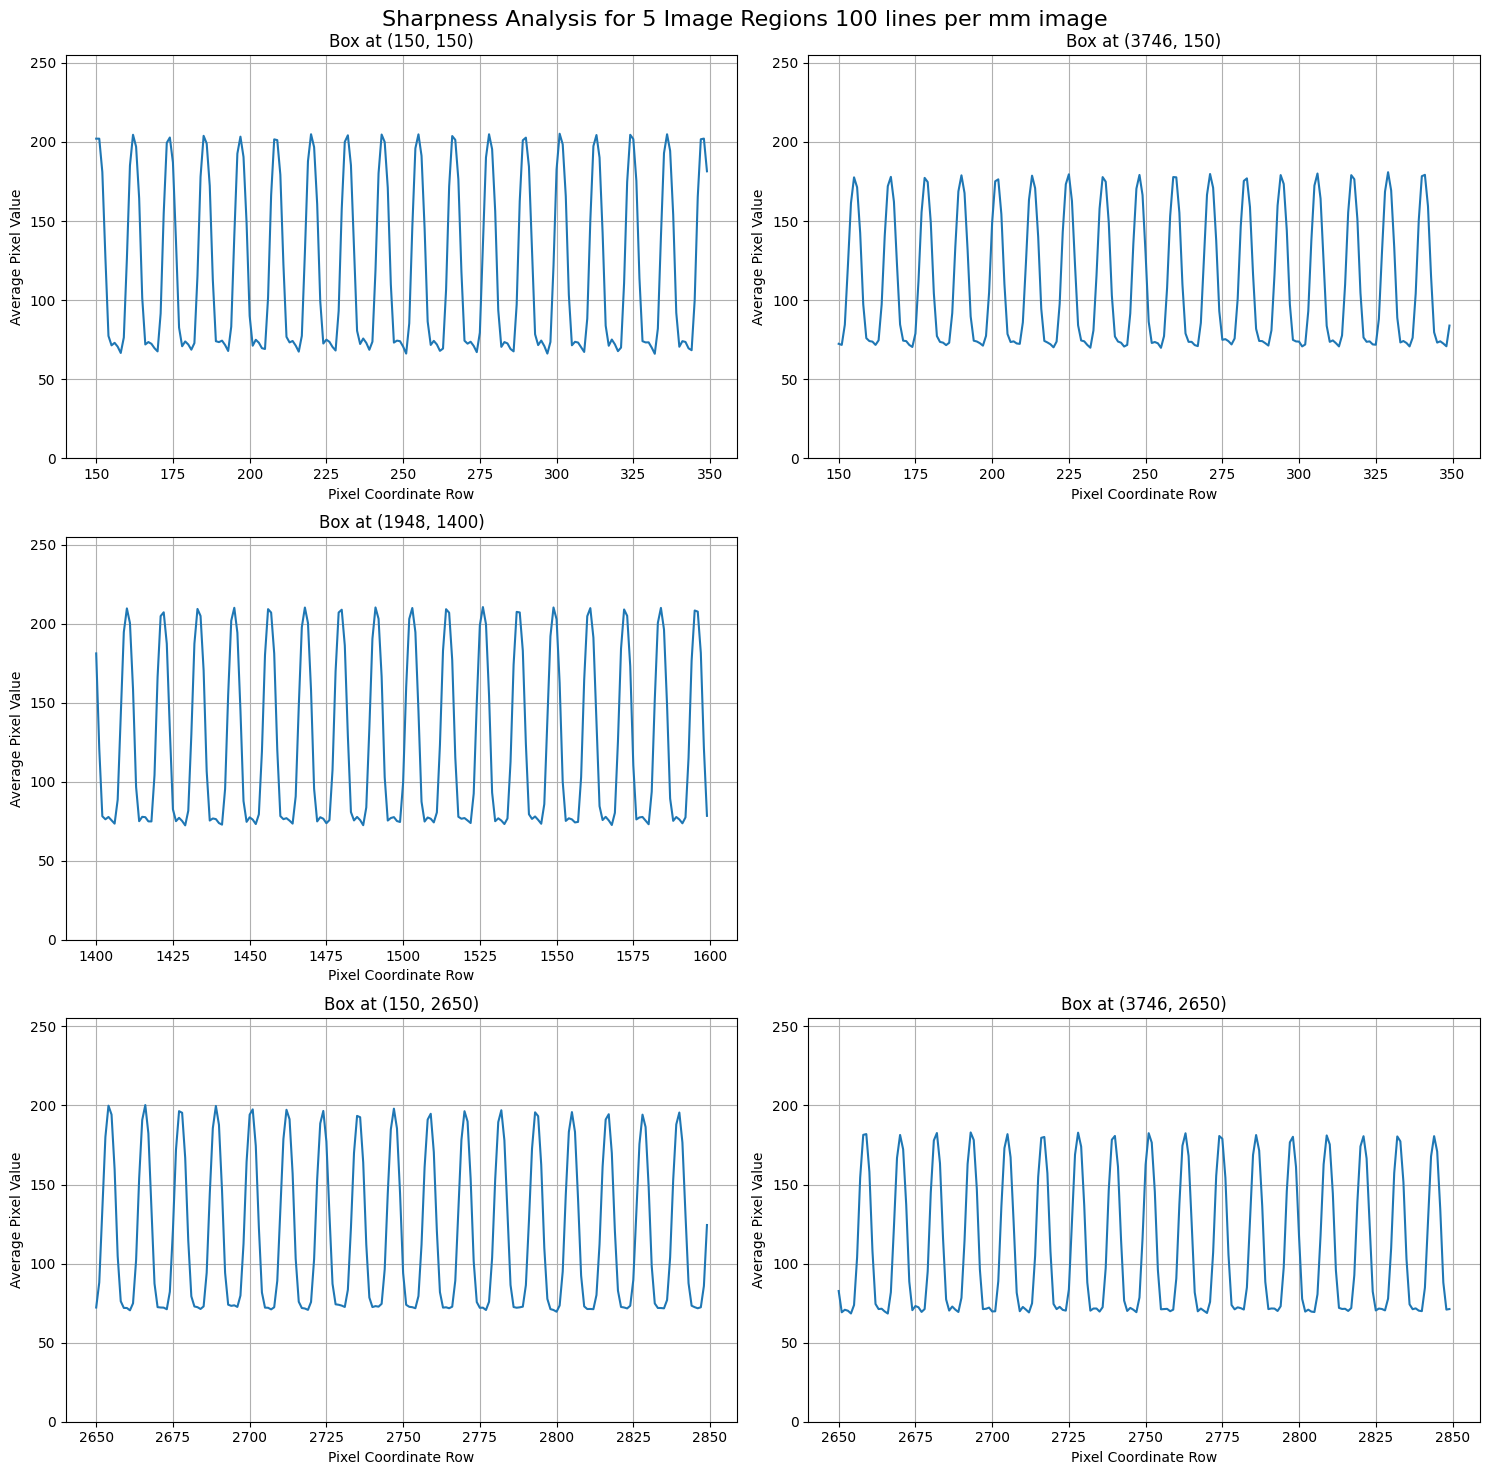

In [14]:

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create a figure
fig = plt.figure(figsize=(15, 15))

# Create a GridSpec layout
gs = GridSpec(3, 2, figure=fig)

# Create the axes for the plots
ax1 = fig.add_subplot(gs[0, 0]) # Top-left
ax2 = fig.add_subplot(gs[0, 1]) # Top-right
ax3 = fig.add_subplot(gs[1, 0]) # Middle-center (spans both columns)
ax4 = fig.add_subplot(gs[2, 0]) # Bottom-left
ax5 = fig.add_subplot(gs[2, 1]) # Bottom-right
    
# Arrange axes to match the desired plot order: TL, TR, Center, BL, BR
plot_axes = [ax1, ax2, ax3, ax4, ax5]

# Read the input image
image_path = r"C:\Users\mj.j\Documents\2025_08_29_lens_eval_new\100_00.png"
image = cv2.imread(image_path)
if image is None:
    print(f"Warning: Could not read image at {image_path}")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Define the order of boxes to match the plot layout
    # Original order: TL, TR, BL, BR, Center
    # Desired plot order: TL, TR, Center, BL, BR
    plot_boxes = [boxes[0], boxes[1], boxes[4], boxes[2], boxes[3]]


    # Iterate over the boxes and the axes to plot
    for i, (x, y) in enumerate(plot_boxes):
        ax = plot_axes[i]
        sum_of_pixel_values = []
        x_start = x
        x_end = x + box_size

        for y_coord in range(y, y + box_size, 1):
            horizontal_line = gray[y_coord, x_start:x_end]
            horizontal_pixel_sum = np.sum(horizontal_line) / box_size
            sum_of_pixel_values.append(horizontal_pixel_sum)

        # Plot on the corresponding subplot axis
        ax.plot(range(y, y + box_size, 1), sum_of_pixel_values)
        ax.set_xlabel("Pixel Coordinate Row")
        ax.set_ylabel("Average Pixel Value")
        ax.grid(True)
        ax.set_ylim(0, 255)
        ax.set_title(f"Box at ({x}, {y})")

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout()
plt.subplots_adjust(top=0.95) # Adjust top to make space for suptitle

# Add a title to the entire figure
fig.suptitle('Sharpness Analysis for 5 Image Regions 100 lines per mm image', fontsize=16)


# Save the entire figure
file_name = f"C:\\Users\\mj.j\\Documents\\2025_08_29_lens_eval_new\\100_00_combined_plot.png"
plt.savefig(file_name, bbox_inches='tight', dpi=100)

# Show the plot
plt.show()